<a href="https://colab.research.google.com/github/skandanyal/ML-Lab-7th-sem/blob/main/mlLab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import os


dataset_base_path = kagglehub.dataset_download("alsaniipe/heart-disease")
print("Path to dataset files:", dataset_base_path)

file_name = "processed.cleveland.data"
full_file_path = os.path.join(dataset_base_path, file_name)

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(full_file_path, header=None, na_values='?', names=column_names)

print("First 5 records of the new dataset:", df.head())

100%|██████████| 139k/139k [00:00<00:00, 17.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alsaniipe/heart-disease/versions/1
First 5 records of the new dataset:     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [2]:
# mentioning all the imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
features = '''
1. age
2. sex - gender
3. cp - chest pain type (4 values)
4. trestbpm - resting blood pressure (in mm Hg)
5. chol - serum cholestoral (in mg/dl)
6. fbs - fasting blood sugar > 120 mg/dl
7. restecg - resting electrocardiographic results (values 0,1,2)
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina
10. oldpeak - ST depression induced by exercise relative to rest
11. slope - the slope of the peak exercise ST segment
12. ca - number of major vessels (0-3) colored by flourosopy
13. thal - 0 = normal; 1 = fixed defect; 2 = reversable defect
14. target - sur
'''

## Data Cleaning

Removing NaN values from the dataset.

In [4]:
# let us look at the features and their datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
# let us look at the central tendencies of the features in the dataset

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
# segregating numerical and categorical data

df_num = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]                          # use histogram
df_cat = df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']]            # value count

In [8]:
df_num.head()

,age,trestbps,chol,thalach,oldpeak
0,63.0,145.0,233.0,150.0,2.3
1,67.0,160.0,286.0,108.0,1.5
2,67.0,120.0,229.0,129.0,2.6
3,37.0,130.0,250.0,187.0,3.5
4,41.0,130.0,204.0,172.0,1.4


In [9]:
df_cat.head()

,sex,cp,fbs,restecg,exang,slope,ca,thal
0,1.0,1.0,1.0,2.0,0.0,3.0,0.0,6.0
1,1.0,4.0,0.0,2.0,1.0,2.0,3.0,3.0
2,1.0,4.0,0.0,2.0,1.0,2.0,2.0,7.0
3,1.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0
4,0.0,2.0,0.0,2.0,0.0,1.0,0.0,3.0


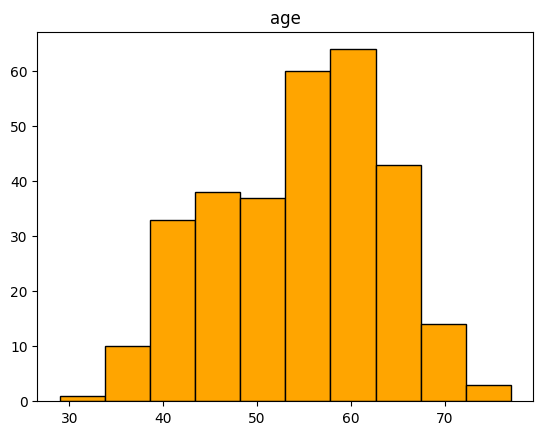

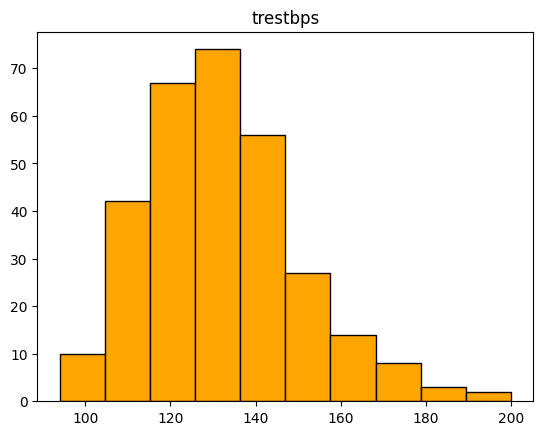

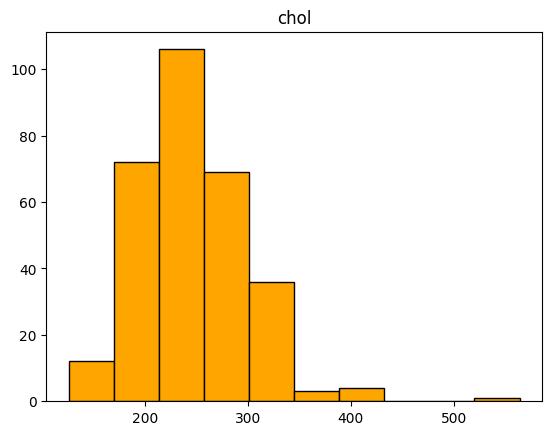

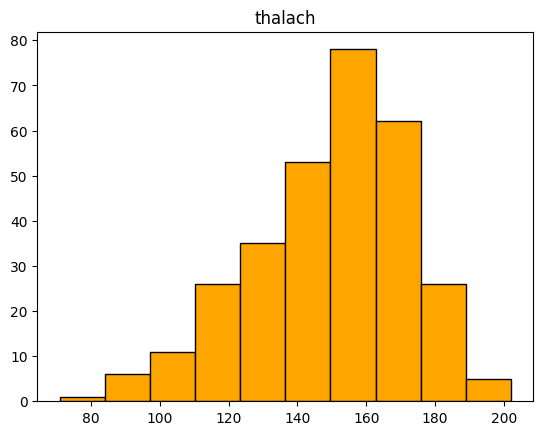

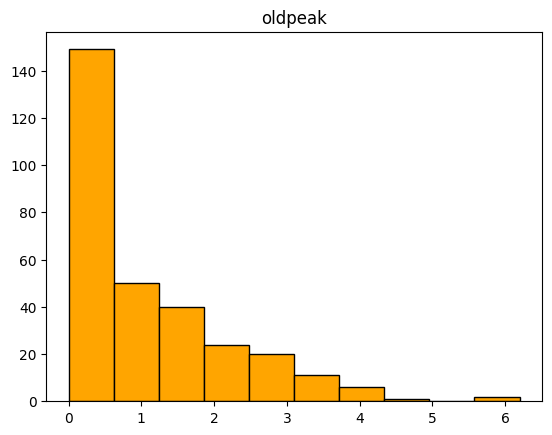

In [10]:
# histograms of all numerical values

for cat in df_num.columns:
    plt.hist(df_num[cat], color='orange', edgecolor='black', )
    plt.title(cat)
    plt.show()

In [11]:
# applying log function to oldpeak

df['log_oldpeak'] = np.log(df['oldpeak'] + 1)

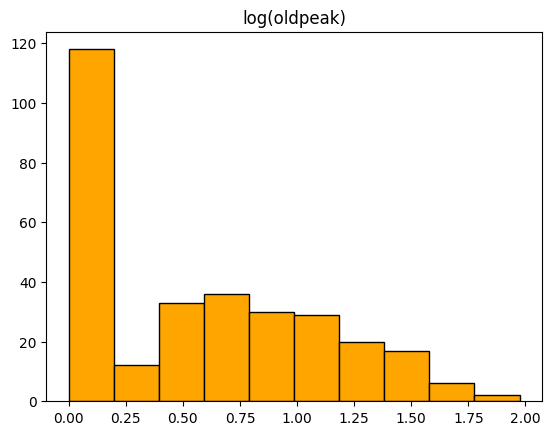

In [12]:
# let us look at the histogram of the transformed metric

plt.hist(df['log_oldpeak'], color='orange', edgecolor='black')
plt.title('log(oldpeak)')
plt.show()

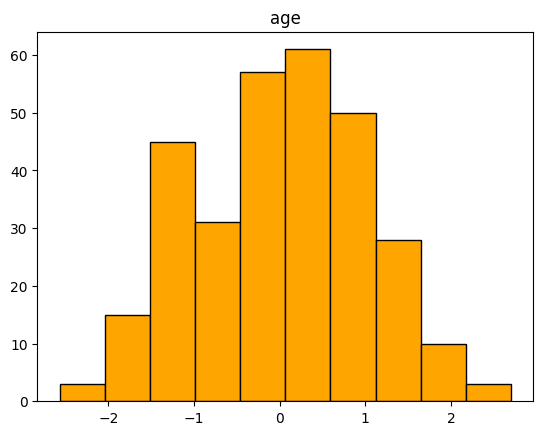

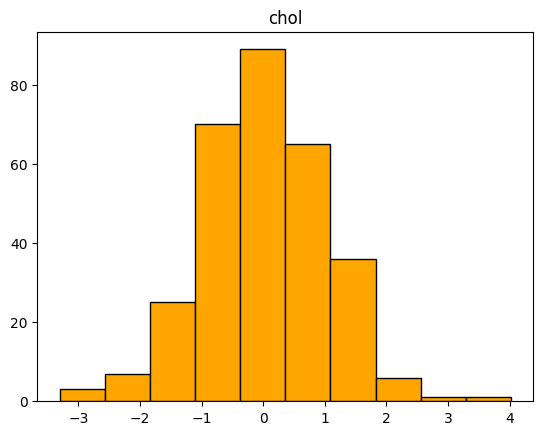

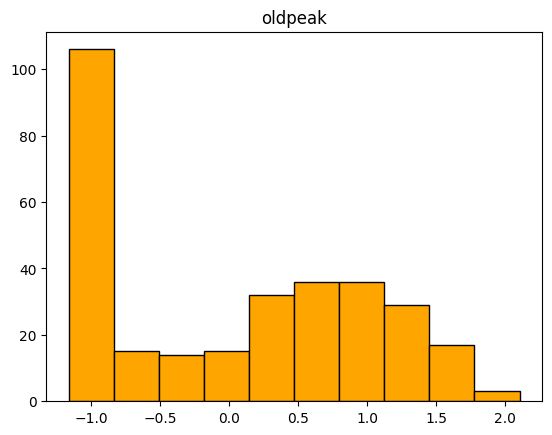

In [13]:
# let us also tranfsorm age and chol along with oldpeak

from sklearn.preprocessing import PowerTransformer

cols = ['age', 'chol', 'oldpeak']
pt = PowerTransformer(method='yeo-johnson')
df_transformed = pd.DataFrame(pt.fit_transform(df[cols]), columns=cols)

for cat in df_transformed.columns:
    plt.hist(df_transformed[cat], color='orange', edgecolor='black')
    plt.title(cat)
    plt.show()

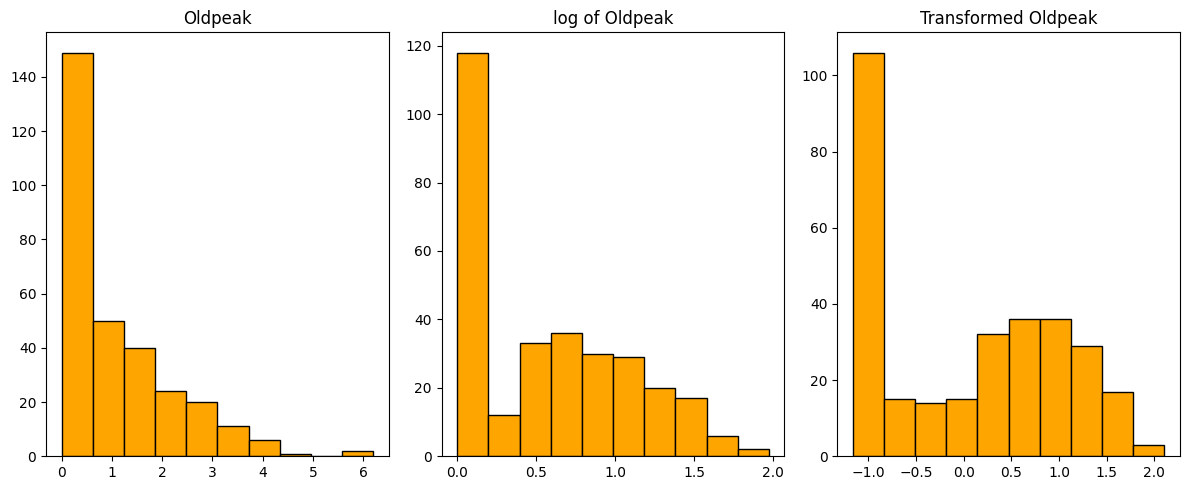

In [14]:
# comparing the original oldpeak, log_oldpeak and transformed oldpeak side by side

fix, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12,5))

ax1.hist(df['oldpeak'], color='orange', edgecolor='black')
ax1.set(title='Oldpeak')

ax2.hist(df['log_oldpeak'], color='orange', edgecolor='black')
ax2.set(title='log of Oldpeak')

ax3.hist(df_transformed['oldpeak'], color='orange', edgecolor='black')
ax3.set(title='Transformed Oldpeak')

plt.tight_layout()
plt.show()

                  age       sex        cp  trestbps      chol       fbs  \
age          1.000000 -0.097542  0.104139  0.284946  0.208950  0.118530   
sex         -0.097542  1.000000  0.010084 -0.064456 -0.199915  0.047862   
cp           0.104139  0.010084  1.000000 -0.036077  0.072319 -0.039975   
trestbps     0.284946 -0.064456 -0.036077  1.000000  0.130120  0.175340   
chol         0.208950 -0.199915  0.072319  0.130120  1.000000  0.009841   
fbs          0.118530  0.047862 -0.039975  0.175340  0.009841  1.000000   
restecg      0.148868  0.021647  0.067505  0.146560  0.171043  0.069564   
thalach     -0.393806 -0.048663 -0.334422 -0.045351 -0.003432 -0.007854   
exang        0.091661  0.146201  0.384060  0.064762  0.061310  0.025665   
oldpeak      0.203805  0.102173  0.202277  0.189171  0.046564  0.005747   
slope        0.161770  0.037533  0.152050  0.117382 -0.004062  0.059894   
ca           0.362605  0.093185  0.233214  0.098773  0.119000  0.145478   
thal         0.127389  0.

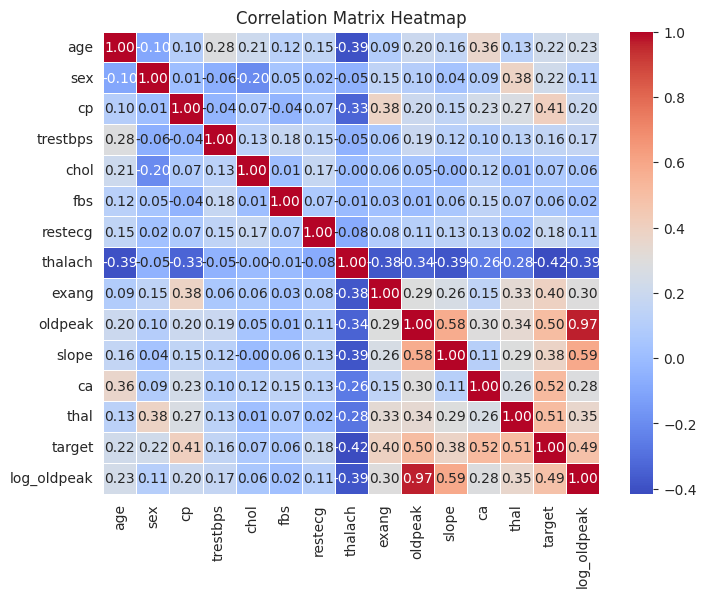

In [15]:
# check for correlation matrix

# calculating correlation matrix
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)  # View correlation values

# Set the background style to white
sns.set_style('white')
sns.palette='viridis'

# Create the heatmap
plt.figure(figsize=(8, 6))  # Adjust the figure size if needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

In [16]:
# we will oneHotEncode all categorical data in the main df

df_cat.columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], dtype='object')

In [17]:
col_names = df.columns
col_names

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'log_oldpeak'],
      dtype='object')

In [18]:
y = df['target']
X = df.drop('target', axis=1)

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_hot = OneHotEncoder()
transformer = ColumnTransformer([
    ('one_hot_encoding', one_hot, df_cat.columns)],
     remainder='passthrough'
)

transformed_X = transformer.fit_transform(X)

In [20]:
transformed_X[:5]

array([[  0.        ,   1.        ,   1.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   1.        ,   1.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          1.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   1.        ,   0.        ,
          0.        ,  63.        , 145.        , 233.        ,
        150.        ,   2.3       ,   1.19392247],
       [  0.        ,   1.        ,   0.        ,   0.        ,
          0.        ,   1.        ,   1.        ,   0.        ,
          0.        ,   0.        ,   1.        ,   0.        ,
          1.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   1.        ,   0.        ,   0.        ,
          0.        ,  67.        , 160.        , 286.        ,
        108.        ,   1.5       ,   0.91629073],
  

In [21]:
# get column names
encoded_cat_cols = transformer.named_transformers_['one_hot_encoding'].get_feature_names_out(df_cat.columns)
num_cols = [col for col in X.columns if col not in df_cat.columns]
all_cols = list(encoded_cat_cols) + num_cols

# wrap in DataFrame
X_t = pd.DataFrame(transformed_X, columns=all_cols)

In [22]:
X_t.head()

,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,...,thal_3.0,thal_6.0,thal_7.0,thal_nan,age,trestbps,chol,thalach,oldpeak,log_oldpeak
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,63.0,145.0,233.0,150.0,2.3,1.193922
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,67.0,160.0,286.0,108.0,1.5,0.916291
2,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,67.0,120.0,229.0,129.0,2.6,1.280934
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,37.0,130.0,250.0,187.0,3.5,1.504077
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,41.0,130.0,204.0,172.0,1.4,0.875469


In [23]:
print(X_t.columns)

Index(['sex_0.0', 'sex_1.0', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0',
       'fbs_1.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'exang_0.0',
       'exang_1.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0',
       'ca_2.0', 'ca_3.0', 'ca_nan', 'thal_3.0', 'thal_6.0', 'thal_7.0',
       'thal_nan', 'age', 'trestbps', 'chol', 'thalach', 'oldpeak',
       'log_oldpeak'],
      dtype='object')


In [24]:
# using cross validation for quicker testing of accuracy of different models

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

models = {
    'RandomForest': RandomForestClassifier(n_jobs=5),
    'LinearSVC': LinearSVC(),
    'GradientBoostingClaf': HistGradientBoostingClassifier(),
    'LogisticRegression': LogisticRegression(random_state=5, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
}


for name, model in models.items():
    scores = cross_val_score(estimator=model, X=X_t, y=y, scoring='accuracy', cv=5, n_jobs=5)
    print(f"{name} -> Mean accuracy: {np.mean(scores):.4f}")

RandomForest -> Mean accuracy: 0.6170
LinearSVC -> Mean accuracy: 0.6072
GradientBoostingClaf -> Mean accuracy: 0.5774
LogisticRegression -> Mean accuracy: 0.6105
KNN -> Mean accuracy: 0.5116
